In [5]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, aberration, equatorial2galactic, galactic2equatorial
import os
import numpy as np
import matplotlib.pyplot as plt
import math

When we change only the yaw or only the pitch, it is as if the star describes a circle, similar to a parallel in the figure below on the left-hand side, around the considered axis (yaw or pitch).  Projecting this onto the CCD is then similar to projecting the parallels to the lines that are more or less horizontal on the plot below on the right-hand side.  If the circle of the parallel is small (i.e. when you are further away from the considered axis), the projected line diverges more and more from the projected equator.

![title](gnomonicProjection.gif)

In [6]:
sim = Simulation("Jitter")
switchOffAllEffects(sim)
sim["ObservingParameters/NumExposures"] = 1
sim.outputDir = os.environ["PLATO_WORKDIR"]

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"

dimColumn = 100
dimRow = 4510
# sim["SubField/SubPixels"] = 1
numSubPixels = sim["SubField/SubPixels"]

sim["SubField/NumRows"] = dimRow
sim["SubField/NumColumns"] = dimColumn

sim["PSF/Model"] = "MappedGaussian"
sim["CCD/IncludeConvolution"] = "no"

sim["Platform/UseJitter"] = "yes"
sim["Platform/UseJitterFromFile"] = "yes"

sim["ObservingParameters/CycleTime"] = sim.getReadoutTime()[0] + 1

In [8]:
jitter = -50
sim["ControlHDF5Content/WriteStarPositions"] = "yes"

In [9]:
jitter2 = jitter / 10 * 250

jitterTimeScale2 = 0.1 * 250 #25
numJitterSteps2 = int(25 / jitterTimeScale2) * 500
time2 = np.arange(numJitterSteps2) * jitterTimeScale2
noChange2 = np.zeros(numJitterSteps2)
change2 = np.arange(numJitterSteps2) * jitter2
jitterFilenameYaw2 = os.environ["PLATO_WORKDIR"] + "yawJitter2.txt"
jitterFilenamePitch2 = os.environ["PLATO_WORKDIR"] + "pitchJitter2.txt"
jitterFilenameRoll2 = os.environ["PLATO_WORKDIR"] + "rollJitter2.txt"

np.savetxt(jitterFilenameYaw2, np.c_[time2, change2, noChange2, noChange2])
np.savetxt(jitterFilenamePitch2, np.c_[time2, noChange2, -change2, noChange2])
np.savetxt(jitterFilenameRoll2, np.c_[time2, noChange2, noChange2, change2])

# Change in yaw only (exaggerated)

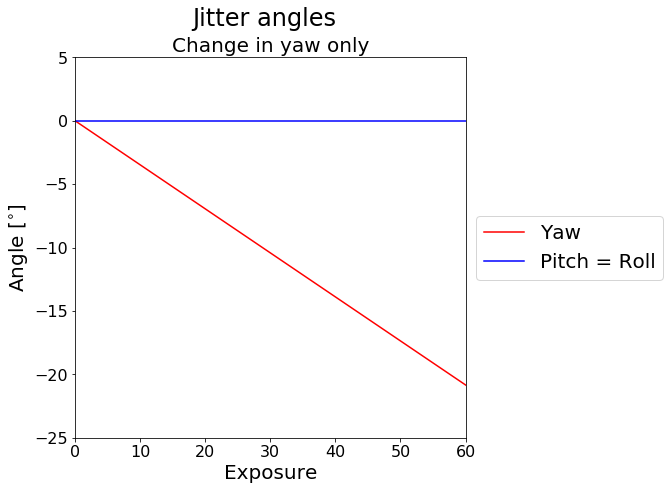

In [10]:
fig = plt.figure(figsize = (7, 7))
ax = fig.add_subplot(1, 1, 1)

plt.plot(time2 / 25, change2 / 3600, "r", label="Yaw")
plt.plot(time2 / 25, noChange2 / 3600, "b", label="Pitch = Roll")

plt.suptitle("Jitter angles", fontsize = 24)
plt.title("Change in yaw only", fontsize = 20)

plt.xlabel("Exposure", fontsize = 20)
plt.ylabel("Angle [$^{\circ}$]", fontsize = 20)

plt.xlim([0, 60])
plt.ylim([-25, 5])

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

Yaw
500


Error: SimfFile.getStarCoordinates(): Exposure000056 not in hdf5 file
[0.11115637 0.223105   0.33584676 0.4493825  0.56371312 0.6788395
 0.79476252 0.91148308 1.0290021  1.14732048 1.26643913 1.38635899
 1.50708099 1.62860605 1.75093514 1.87406919 1.99800918 2.12275605
 2.24831079 2.37467438 2.50184779 2.62983203 2.7586281  2.88823699
 3.01865973 3.14989733 3.28195083 3.41482125 3.54850965 3.68301706
 3.81834454 3.95449317 4.091464   4.22925812 4.3678766  4.50732055
 4.64759106 4.78868924 4.9306162  5.07337306 5.21696095 5.361381
 5.50663437 5.65272219 5.79964563 5.94740585 6.09600402 6.24544133
 6.39571895 6.5468381  6.69879996 6.85160575 7.00525669 7.159754
 7.31509891 7.47129267]
1500


Error: SimfFile.getStarCoordinates(): Exposure000056 not in hdf5 file
[ 0.33346912  0.66931501  1.00754027  1.34814751  1.69113936  2.03651849
  2.38428755  2.73444925  3.0870063   3.44196144  3.7993174   4.15907698
  4.52124296  4.88581816  5.25280542  5.62220758  5.99402753  6.36826815
  

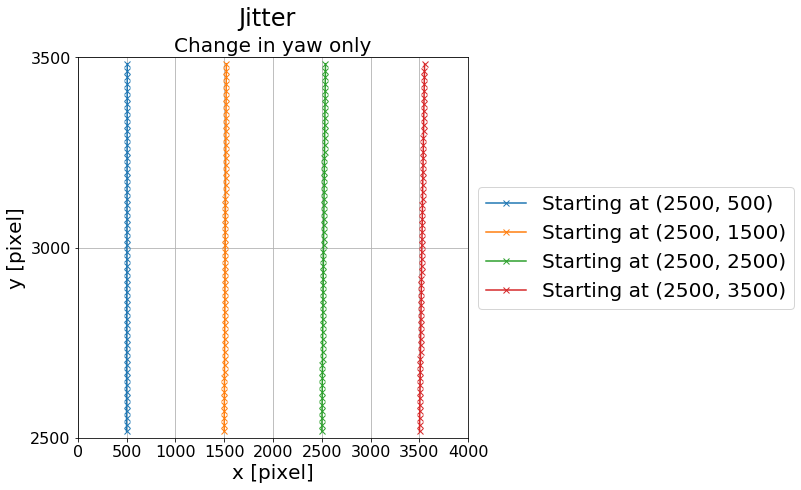

In [11]:
sim["Platform/JitterFileName"] = jitterFilenameYaw2

numExposures = 60
sim["ObservingParameters/NumExposures"] = numExposures

delta = 2500

dimColumn = 100
dimRow = 1000

sim["SubField/NumRows"] = dimRow
sim["SubField/NumColumns"] = dimColumn

fig = plt.figure(figsize = (7, 7))
ax = fig.add_subplot(1, 1, 1)

print("Yaw")

for position in np.arange(500, 4500, 1000):
    
    print(position)
    
    label = "Starting at (" + str(delta) + ", " + str(position) + ")"
    sim.createStarCatalogFileFromPixelCoordinates(np.array([delta]), np.array([position]), np.array([12.5]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename
    
    sim["SubField/ZeroPointRow"] = delta
    sim["SubField/ZeroPointColumn"] = position
    
    output = sim.run(removeOutputFile = True)
    
    rows = np.array([])
    columns = np.array([])

    for exposure in range(numExposures):
        try:
            ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
            rows = np.append(rows, row)
            columns = np.append(columns, column)
        except:
            break
    
        
    plt.plot(columns + position, rows + delta, marker="x", label=label)
    
    print(columns)
    
plt.legend(loc='best', fontsize = 20)

########
# Layout
########

plt.suptitle("Jitter", fontsize = 24)
plt.title("Change in yaw only", fontsize = 20)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)

ax.set_xticks(np.arange(0, 5000, 500))
ax.set_yticks(np.arange(delta, 5000, 500))
plt.grid()

plt.xlabel("x [pixel]", fontsize = 20)
plt.ylabel("y [pixel]", fontsize = 20)

plt.xlim([0, 4000])
plt.ylim([delta, delta + dimRow])

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

# Change in pitch only (exaggerated)

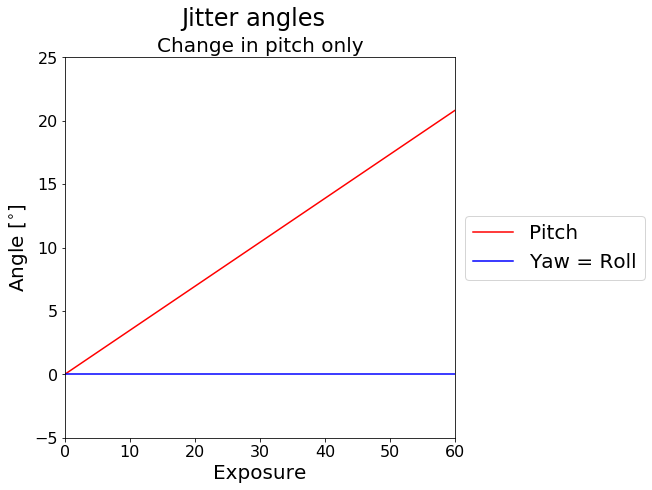

In [12]:
fig = plt.figure(figsize = (7, 7))
ax = fig.add_subplot(1, 1, 1)

plt.plot(time2 / 25, -change2 / 3600, "r", label="Pitch")
plt.plot(time2 / 25, noChange2 / 3600, "b", label="Yaw = Roll")

plt.suptitle("Jitter angles", fontsize = 24)
plt.title("Change in pitch only", fontsize = 20)

plt.xlabel("Exposure", fontsize = 20)
plt.ylabel("Angle [$^{\circ}$]", fontsize = 20)

plt.xlim([0, 60])
plt.ylim([-5, 25])

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

Pitch
500


Error: SimfFile.getStarCoordinates(): Exposure000056 not in hdf5 file
[ 17.31288418  34.63349354  51.96188472  69.29811445  86.64223956
 103.99431699 121.35440377 138.72255701 156.09883397 173.48329196
 190.87598842 208.2769809  225.68632703 243.10408457 260.53031136
 277.96506537 295.40840467 312.86038742 330.32107193 347.79051657
 365.26877987 382.75592042 400.25199697 417.75706836 435.27119354
 452.79443158 470.32684168 487.86848312 505.41941534 522.97969788
 540.54939039 558.12855264 575.71724455 593.31552612 610.9234575
 628.54109895 646.16851088 663.80575378 681.4528883  699.10997522
 716.77707542 734.45424993 752.1415599  769.83906661 787.54683149
 805.26491608 822.99338206 840.73229124 858.48170557 876.24168714
 894.01229818 911.79360103 929.5856582  947.38853232 965.20228618
 983.02698269]
1500


Error: SimfFile.getStarCoordinates(): Exposure000056 not in hdf5 file
[ 17.31288418  34.63349354  51.96188472  69.29811445  86.64223956
 103.99431699 121.35440377 138.7225

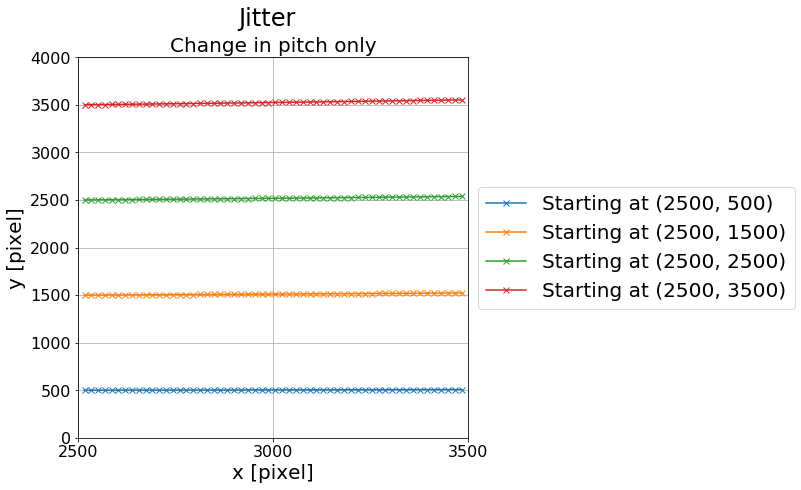

In [13]:
sim["Platform/JitterFileName"] = jitterFilenamePitch2

numExposures = 60
sim["ObservingParameters/NumExposures"] = numExposures

delta = 2500

dimColumn = 1000
dimRow = 100

sim["SubField/NumRows"] = dimRow
sim["SubField/NumColumns"] = dimColumn

fig = plt.figure(figsize = (7, 7))
ax = fig.add_subplot(1, 1, 1)

print("Pitch")

for position in np.arange(500, 4500, 1000):
    
    print(position)
    
    label = "Starting at (" + str(delta) + ", " + str(position) + ")"
    sim.createStarCatalogFileFromPixelCoordinates(np.array([position]), np.array([delta]), np.array([12.5]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename
    
    sim["SubField/ZeroPointRow"] = position
    sim["SubField/ZeroPointColumn"] = delta
    
    output = sim.run(removeOutputFile = True)
    
    rows = np.array([])
    columns = np.array([])

    for exposure in range(numExposures):
        try:
            ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
            rows = np.append(rows, row)
            columns = np.append(columns, column)
        except:
            break
    
        
    plt.plot(columns + delta, rows + position, marker="x", label=label)
    
    print(columns)
    
plt.legend(loc='best', fontsize = 20)

########
# Layout
########

plt.suptitle("Jitter", fontsize = 24)
plt.title("Change in pitch only", fontsize = 20)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)

ax.set_yticks(np.arange(0, 5000, 500))
ax.set_xticks(np.arange(delta, 5000, 500))
plt.grid()

plt.xlabel("x [pixel]", fontsize = 20)
plt.ylabel("y [pixel]", fontsize = 20)

plt.ylim([0, 4000])
plt.xlim([delta, delta + dimColumn])

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

# Change in roll only (exaggerated)

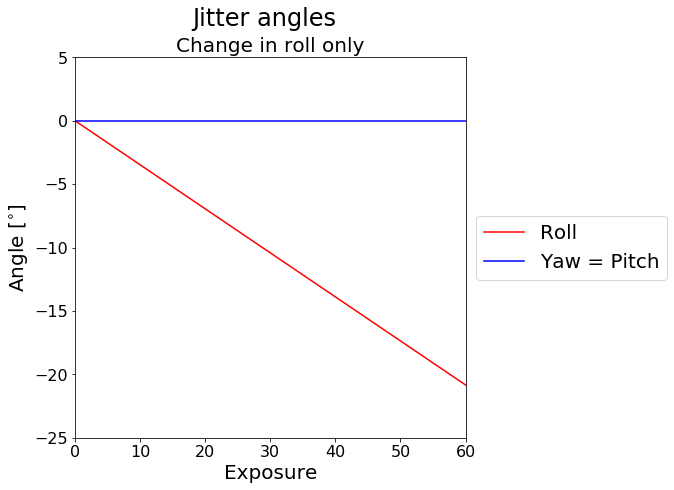

In [14]:
fig = plt.figure(figsize = (7, 7))
ax = fig.add_subplot(1, 1, 1)

plt.plot(time2 / 25, change2 / 3600, "r", label="Roll")
plt.plot(time2 / 25, noChange2 / 3600, "b", label="Yaw = Pitch")

plt.suptitle("Jitter angles", fontsize = 24)
plt.title("Change in roll only", fontsize = 20)

plt.xlabel("Exposure", fontsize = 20)
plt.ylabel("Angle [$^{\circ}$]", fontsize = 20)

plt.xlim([0, 60])
plt.ylim([-25, 5])

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

Pitch
10


20


30


40




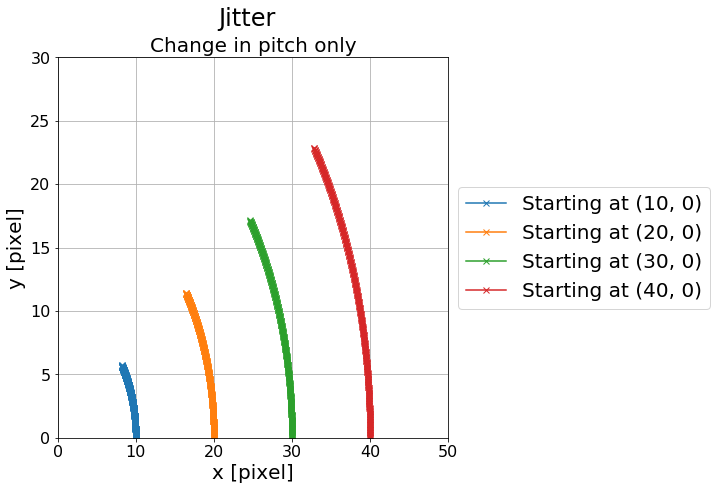

In [15]:
sim["Platform/JitterFileName"] = jitterFilenameRoll2

numExposures = 500
sim["ObservingParameters/NumExposures"] = numExposures

delta = 0

dimColumn = 50
dimRow = 50

sim["SubField/NumRows"] = dimRow
sim["SubField/NumColumns"] = dimColumn

fig = plt.figure(figsize = (7, 7))
ax = fig.add_subplot(1, 1, 1)

print("Pitch")

for position in np.arange(10, 50, 10):
    
    print(position)
    
    label = "Starting at (" + str(position) + ", " + str(delta) + ")"
    sim.createStarCatalogFileFromPixelCoordinates(np.array([delta]), np.array([position]), np.array([12.5]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename
    
    sim["SubField/ZeroPointRow"] = 0
    sim["SubField/ZeroPointColumn"] = 0
    
    output = sim.run(removeOutputFile = True)
    
    rows = np.array([])
    columns = np.array([])

    for exposure in range(numExposures):
        try:
            ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
            rows = np.append(rows, row)
            columns = np.append(columns, column)
        except:
            break
    
        
    plt.plot(columns, rows, marker="x", label=label)
    
plt.legend(loc='best', fontsize = 20)

########
# Layout
########

plt.suptitle("Jitter", fontsize = 24)
plt.title("Change in pitch only", fontsize = 20)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)

# ax.set_yticks(np.arange(0, 5000, 500))
# ax.set_xticks(np.arange(delta, 5000, 500))
plt.grid()

plt.xlabel("x [pixel]", fontsize = 20)
plt.ylabel("y [pixel]", fontsize = 20)

plt.ylim([0, 30])
plt.xlim([delta, delta + 50])

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

# Auto-generated TED

In [17]:
sim["Platform/UseJitterFromFile"] = "no"

rmsYaw = 2.0
rmsPitch = 3.0
rmsRoll = 4.0

sim["Platform/JitterYawRms"] = rmsYaw
sim["Platform/JitterPitchRms"] = rmsPitch
sim["Platform/JitterRollRms"] = rmsRoll

sim["SubField/NumRows"] = 1
sim["SubField/NumColumns"] = 1

numExposures = 1000
sim["ObservingParameters/NumExposures"] = numExposures
output = sim.run(removeOutputFile = True)


2020-01-21 15:26:26 WARNING Simulation: no information about detected stars to write to HDF5
2020-01-21 15:26:26 WARNING Camera: No star positions to write to HDF5 file.



In [18]:
yaw, pitch, roll = output.getYawPitchRoll()

In [19]:
def rms(data):
    
    return np.sqrt(np.mean(np.square(data)))

In [21]:
timestep = sim["ObservingParameters/CycleTime"]
timescale = sim["Platform/JitterTimeScale"]

deltaYaw = (yaw[1:] - math.exp(-timestep / timescale) * yaw[:-1]) / math.sqrt(timestep / timescale)
deltaPitch = (pitch[1:] - math.exp(-timestep / timescale) * pitch[:-1]) / math.sqrt(timestep / timescale)
deltaRoll = (roll[1:] - math.exp(-timestep / timescale) * roll[:-1]) / math.sqrt(timestep / timescale)

# plt.plot(deltaYaw)
print(np.std(deltaYaw))
print(rms(deltaYaw))

print(np.std(deltaPitch))
print(rms(deltaPitch))

print(np.std(deltaRoll))
print(rms(deltaRoll))

2.7600438231510833
2.7600460274805543
4.2530206696268795
4.253936785472626
5.700754331267203
5.701289790875151


### Yaw

Text(0, 0.5, 'Yaw [degrees]')

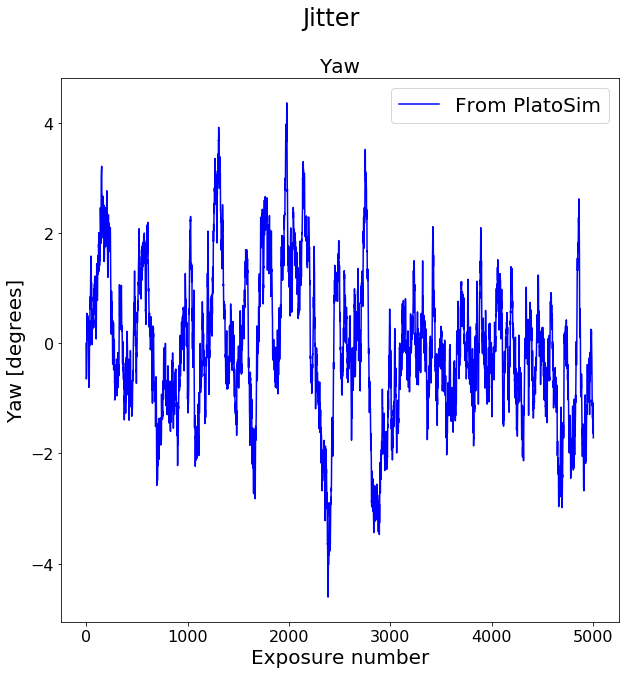

In [87]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(yaw, "b", label = "From PlatoSim")




########
# Layout
########

plt.suptitle("Jitter", fontsize = 24)
plt.title("Yaw", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Yaw [degrees]", fontsize = 20)

Text(0, 0.5, 'PSD')

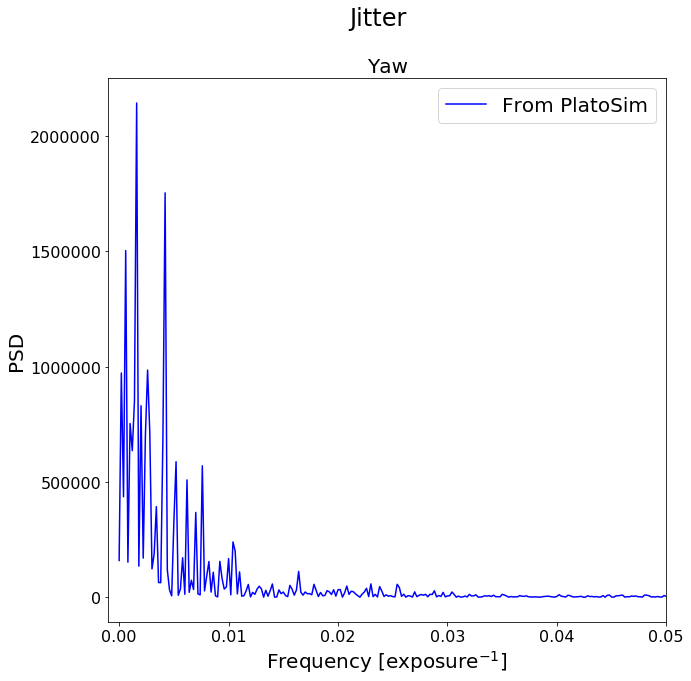

In [90]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

fs = 1
xF = np.fft.fft(yaw)
N = len(xF)
xF = xF[0:int(N//2)]
fr = np.linspace(0,fs/2,int(N//2))

plt.plot(fr, abs(xF)**2, "b", label = "From PlatoSim")



###########
# Red noise
###########

frNonZero = fr[fr != 0]
redNoise = 1 / frNonZero**2

# plt.plot(frNonZero, redNoise, "r", label = "Red noise ($1 / f^2)$")



########
# Layout
########

plt.xlim([-0.001, 0.05])
# plt.ylim([0, 2500])

plt.suptitle("Jitter", fontsize = 24)
plt.title("Yaw", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Frequency [exposure$^{-1}$]", fontsize = 20)
plt.ylabel("PSD", fontsize = 20)

### Pitch

Text(0, 0.5, 'Pitch [degrees]')

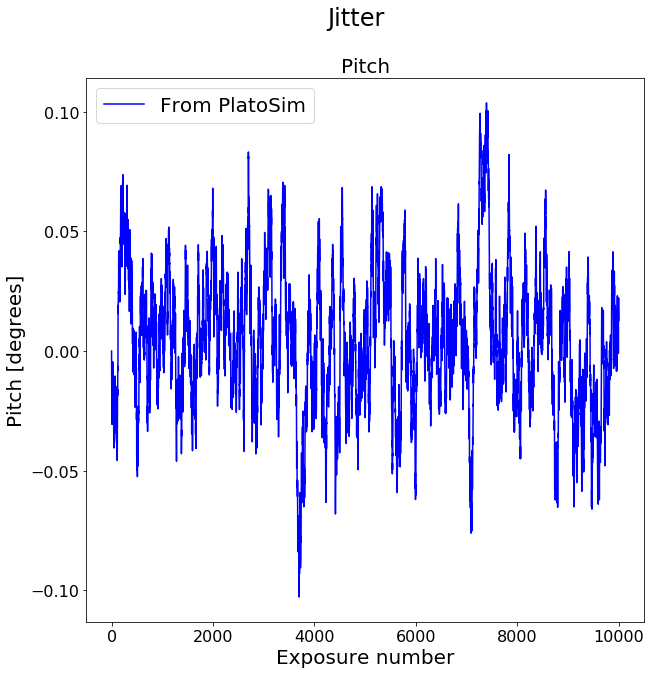

In [53]:
fig = plt.figure(figsize = (10, 10))



###############
# From PlatoSim
###############

ax = fig.add_subplot(1, 1, 1)
plt.plot(pitch, "b", label = "From PlatoSim")




########
# Layout
########

plt.suptitle("Jitter", fontsize = 24)
plt.title("Pitch", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Pitch [degrees]", fontsize = 20)

Text(0, 0.5, 'PSD')

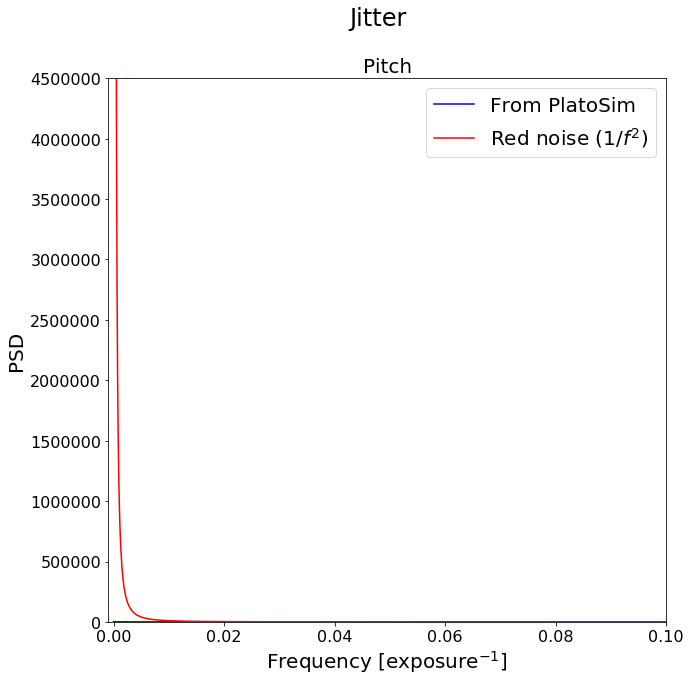

In [54]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

fs = 1
xF = np.fft.fft(pitch)
N = len(xF)
xF = xF[0:int(N//2)]
fr = np.linspace(0,fs/2,int(N//2))

plt.plot(fr, abs(xF)**2, "b", label = "From PlatoSim")



###########
# Red noise
###########

frNonZero = fr[fr != 0]
redNoise = 1 / frNonZero**2

plt.plot(frNonZero, redNoise, "r", label = "Red noise ($1 / f^2)$")



########
# Layout
########

plt.xlim([-0.001, 0.1])
plt.ylim([0, 4500000])

plt.suptitle("Jitter", fontsize = 24)
plt.title("Pitch", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Frequency [exposure$^{-1}$]", fontsize = 20)
plt.ylabel("PSD", fontsize = 20)

### Roll

Text(0, 0.5, 'Roll [degrees]')

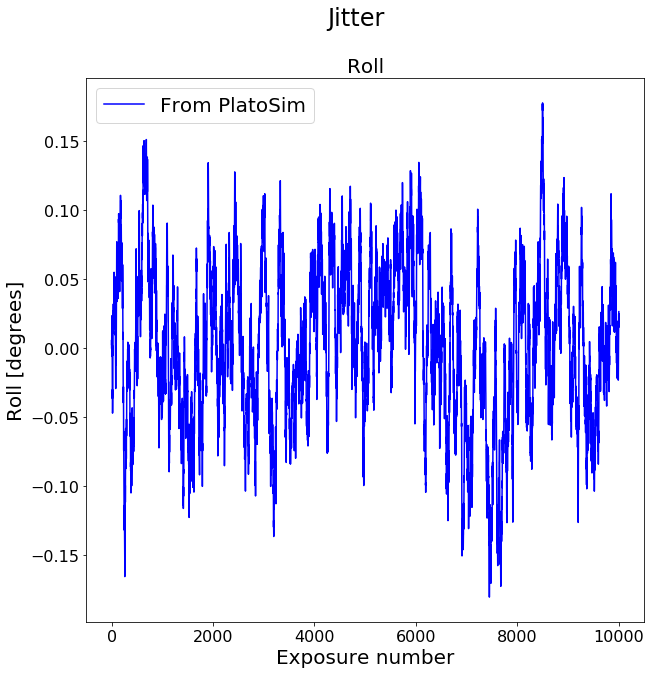

In [55]:
fig = plt.figure(figsize = (10, 10))



###############
# From PlatoSim
###############

ax = fig.add_subplot(1, 1, 1)
plt.plot(roll, "b", label = "From PlatoSim")




########
# Layout
########

plt.suptitle("Jitter", fontsize = 24)
plt.title("Roll", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Roll [degrees]", fontsize = 20)

Text(0, 0.5, 'PSD')

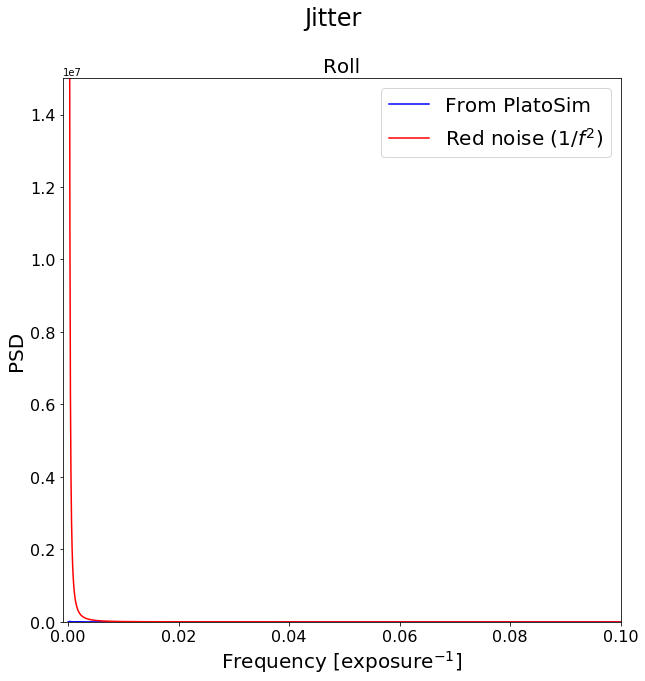

In [56]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

fs = 1
xF = np.fft.fft(roll)
N = len(xF)
xF = xF[0:int(N//2)]
fr = np.linspace(0,fs/2,int(N//2))

plt.plot(fr, abs(xF)**2, "b", label = "From PlatoSim")



###########
# Red noise
###########

frNonZero = fr[fr != 0]
redNoise = 1 / frNonZero**2

plt.plot(frNonZero, redNoise, "r", label = "Red noise ($1 / f^2)$")



########
# Layout
########

plt.xlim([-0.001, 0.1])
plt.ylim([0, 15000000])

plt.suptitle("Jitter", fontsize = 24)
plt.title("Roll", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Frequency [exposure$^{-1}$]", fontsize = 20)
plt.ylabel("PSD", fontsize = 20)